In [2]:
# Loan Eligibility Prediction Project

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Step 1: Create Dataset

data = {
    "Gender": ["Male","Female","Male","Male","Female","Male","Female","Male","Female","Male","Male","Female","Male","Female","Male"],
    "Married": ["Yes","No","Yes","Yes","No","Yes","No","Yes","No","Yes","Yes","No","Yes","No","Yes"],
    "Education": ["Graduate","Graduate","Not Graduate","Graduate","Graduate","Not Graduate","Graduate","Graduate","Not Graduate","Graduate","Graduate","Graduate","Not Graduate","Graduate","Graduate"],
    "Self_Employed": ["No","No","Yes","No","No","Yes","No","No","Yes","No","No","No","Yes","No","No"],
    "ApplicantIncome": [5000,3000,4000,6000,2500,3500,4500,7000,2800,8000,5200,3100,3900,4700,9000],
    "CoapplicantIncome": [2000,0,1500,2500,0,1200,1800,3000,0,3500,2200,0,1100,1600,4000],
    "LoanAmount": [150,100,120,200,80,90,130,250,70,300,170,95,115,140,350],
    "Loan_Amount_Term": [360,360,360,360,180,360,360,360,180,360,360,180,360,360,360],
    "Credit_History": [1,1,0,1,1,0,1,1,0,1,1,1,0,1,1],
    "Property_Area": ["Urban","Rural","Urban","Semiurban","Urban","Rural","Semiurban","Urban","Rural","Urban","Semiurban","Rural","Urban","Semiurban","Urban"],
    "Loan_Status": ["Y","Y","N","Y","Y","N","Y","Y","N","Y","Y","Y","N","Y","Y"]
}

df = pd.DataFrame(data)

print("Loan Eligibility Prediction Project")
print("\nDataset Preview:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Loan Eligibility Prediction Project

Dataset Preview:
   Gender Married     Education Self_Employed  ApplicantIncome  \
0    Male     Yes      Graduate            No             5000   
1  Female      No      Graduate            No             3000   
2    Male     Yes  Not Graduate           Yes             4000   
3    Male     Yes      Graduate            No             6000   
4  Female      No      Graduate            No             2500   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               2000         150               360               1   
1                  0         100               360               1   
2               1500         120               360               0   
3               2500         200               360               1   
4                  0          80               180               1   

  Property_Area Loan_Status  
0         Urban           Y  
1         Rural           Y  
2         Urban           N  
3     Se

In [3]:
# Step 2: Feature Engineering

df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df["EMI"] = df["LoanAmount"] / df["Loan_Amount_Term"]
df["Income_to_Loan_Ratio"] = df["TotalIncome"] / df["LoanAmount"]

print("\nUpdated Dataset with Engineered Features:")
print(df.head())


Updated Dataset with Engineered Features:
   Gender Married     Education Self_Employed  ApplicantIncome  \
0    Male     Yes      Graduate            No             5000   
1  Female      No      Graduate            No             3000   
2    Male     Yes  Not Graduate           Yes             4000   
3    Male     Yes      Graduate            No             6000   
4  Female      No      Graduate            No             2500   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               2000         150               360               1   
1                  0         100               360               1   
2               1500         120               360               0   
3               2500         200               360               1   
4                  0          80               180               1   

  Property_Area Loan_Status  TotalIncome       EMI  Income_to_Loan_Ratio  
0         Urban           Y         7000  0.416667             4

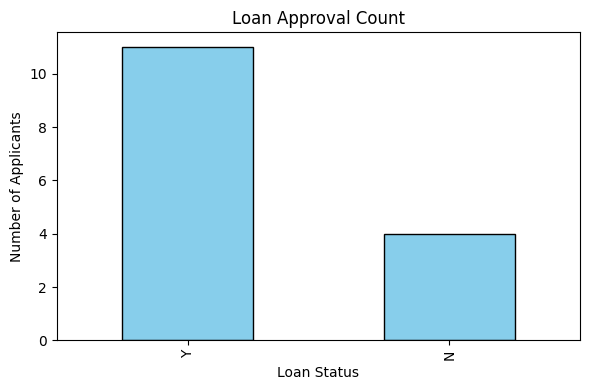

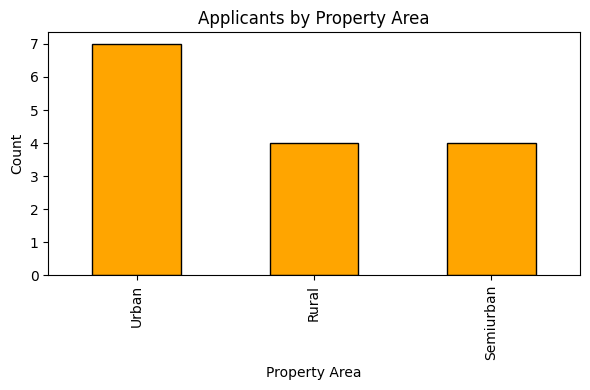

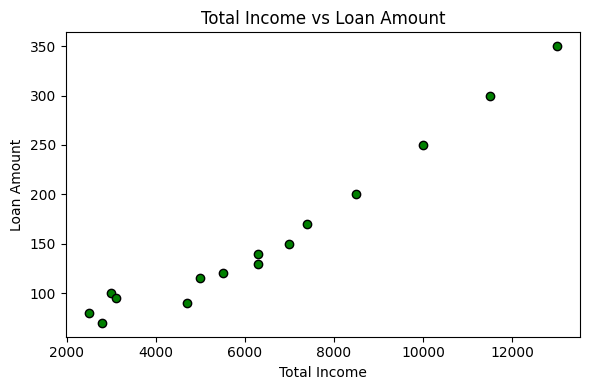

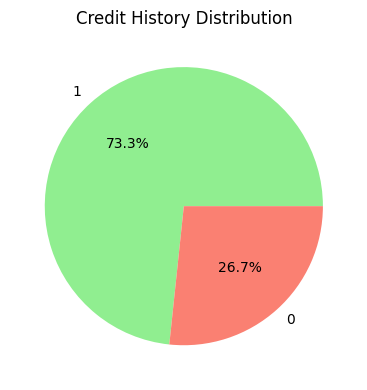

In [4]:
# Step 3: Visualizations

plt.figure(figsize=(6,4))
df["Loan_Status"].value_counts().plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Loan Approval Count")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
df["Property_Area"].value_counts().plot(kind="bar", color="orange", edgecolor="black")
plt.title("Applicants by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["TotalIncome"], df["LoanAmount"], color="green", edgecolor="black")
plt.title("Total Income vs Loan Amount")
plt.xlabel("Total Income")
plt.ylabel("Loan Amount")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
df["Credit_History"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["lightgreen","salmon"])
plt.title("Credit History Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [12]:
# Step 4: Encoding Categorical Variables

label_encoders = {}
for column in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [13]:
# Step 5: Train-Test Split

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [14]:
# Step 6: Model Training

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# Step 7: Model Evaluation

y_pred = model.predict(X_test)

print("\nModel Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Model Evaluation
Accuracy: 1.0

Confusion Matrix:
 [[4]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



Feature Importance:
                 Feature  Importance
3          Self_Employed    0.189246
2              Education    0.178643
8         Credit_History    0.157613
4        ApplicantIncome    0.114319
12  Income_to_Loan_Ratio    0.085190
11                   EMI    0.083332
5      CoapplicantIncome    0.075165
10           TotalIncome    0.050964
6             LoanAmount    0.046524
9          Property_Area    0.008123
1                Married    0.007334
0                 Gender    0.003547
7       Loan_Amount_Term    0.000000


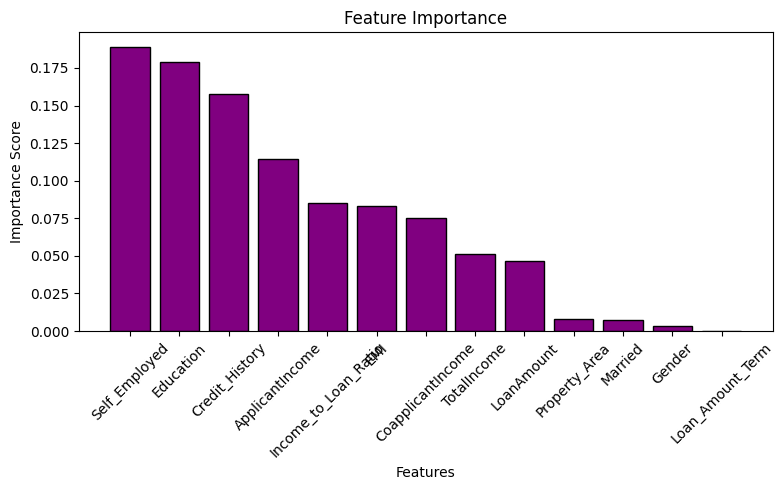

In [9]:
# Step 8: Feature Importance

features = X.columns
importance = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_df)

plt.figure(figsize=(8,5))
plt.bar(feature_df["Feature"], feature_df["Importance"], color="purple", edgecolor="black")
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Step 9: Predict New Applicant

new_applicant = pd.DataFrame({
    "Gender": [1],                
    "Married": [1],               
    "Education": [0],           
    "Self_Employed": [0],         
    "ApplicantIncome": [6000],
    "CoapplicantIncome": [2000],
    "LoanAmount": [180],
    "Loan_Amount_Term": [360],
    "Credit_History": [1],
    "Property_Area": [2],        
    "TotalIncome": [8000],
    "EMI": [180 / 360],
    "Income_to_Loan_Ratio": [8000 / 180]
})

prediction = model.predict(new_applicant)

print("\nNew Applicant Prediction:")
print("Loan Status:", "Approved" if prediction[0] == 1 else "Not Approved")


New Applicant Prediction:
Loan Status: Approved
